In [ ]:
import SF_titled_Influencer
# import Model2
import matplotlib.pyplot as plt
import numpy as np
import random
import SF_26
import random

In [ ]:
def run_sim(G, max_iteration):
    num_iteration = 0
    opinion_history = []
    while num_iteration < max_iteration and not G.consensus_reached(0.001) and not G.opinions_stabilized(0.0000001):
        for node in G.graph.nodes():
            neighbors = list(G.graph.neighbors(node))
                
            weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
            new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
            G.agents[node].opinion = new_opinion
        num_iteration += 1
        opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
        opinion_history.append(opinions_snapshot)
    num_nodes = G.num_of_nodes
    time_steps = range(num_iteration)
    return opinion_history, num_nodes, time_steps

E3

In [ ]:
max_iteration = 2000
num_runs = 100
random_seed = 0

all_opinions_s6 = []  
all_counts_above_08 = []  

for run in range(num_runs):
    random_state = np.random.RandomState(random_seed + run)  
    G = SF_titled_Influencer.SFNetwork(100, 1400, 30, 30, 0, True, 5, random_state)
    opinion_history, num_nodes, time_steps = run_sim(G, max_iteration)

    ave_opinion = []
    count_above_08 = []
    
    for t in time_steps:
        opinions = opinion_history[t]
        ave_opinion.append(np.mean(opinions))
        count_above_08.append(np.sum(np.array(opinions) > 0.8)-100)  

    # Pad if simulation ends early
    if len(ave_opinion) < max_iteration:
        ave_opinion += [ave_opinion[-1]] * (max_iteration - len(ave_opinion))
        count_above_08 += [count_above_08[-1]] * (max_iteration - len(count_above_08))

    all_opinions_s6.append(ave_opinion[:max_iteration])
    all_counts_above_08.append(count_above_08[:max_iteration])

# Convert to np arrays for processing
all_opinions_s6 = np.array(all_opinions_s6)  
all_counts_above_08 = np.array(all_counts_above_08)  

# Compute mean and std
mean_opinion_s6 = np.mean(all_opinions_s6, axis=0)
std_opinion_s6 = np.std(all_opinions_s6, axis=0)

mean_count_above_08_s6 = np.mean(all_counts_above_08, axis=0)
std_count_above_08_s6 = np.std(all_counts_above_08, axis=0)

In [ ]:
all_opinions_s5 = []

for run in range(num_runs):
    random_state = np.random.RandomState(random_seed + run)  
    G = SF_titled_Influencer.SFNetwork(100, 1400, 30, 30, 0, False, 5, random_state)
    opinion_history, num_nodes, time_steps = run_sim(G, max_iteration)
    
    # Average opinion at each time step
    ave_opinion = [np.average(opinion_history[t]) for t in time_steps]
    
    # Pad if simulation ends early
    if len(ave_opinion) < max_iteration:
        ave_opinion += [ave_opinion[-1]] * (max_iteration - len(ave_opinion))
    
    all_opinions_s5.append(ave_opinion[:max_iteration])

# Convert to np array for easy computation
all_opinions_s5 = np.array(all_opinions_s5)  

# Compute average and std over 100 runs
mean_opinion_s5 = np.mean(all_opinions_s5, axis=0)
std_opinion_s5 = np.std(all_opinions_s5, axis=0)

In [ ]:
max_iteration = 2000
num_runs = 100
random_seed = 42

all_opinions_s5 = []  
all_counts_above_08_s5 = []  

for run in range(num_runs):
    random_state = np.random.RandomState(random_seed + run)  
    G = SF_titled_Influencer.SFNetwork(100, 1400, 30, 30, 0, False, 5, random_state)
    opinion_history, num_nodes, time_steps = run_sim(G, max_iteration)

    ave_opinion = []
    count_above_08 = []
    
    for t in time_steps:
        opinions = opinion_history[t]
        ave_opinion.append(np.mean(opinions))
        count_above_08.append(np.sum(np.array(opinions) > 0.8)-100)  

    # Pad if simulation ends early
    if len(ave_opinion) < max_iteration:
        ave_opinion += [ave_opinion[-1]] * (max_iteration - len(ave_opinion))
        count_above_08 += [count_above_08[-1]] * (max_iteration - len(count_above_08))

    all_opinions_s5.append(ave_opinion[:max_iteration])
    all_counts_above_08_s5.append(count_above_08[:max_iteration])

# Convert to np arrays for processing
all_opinions_s5 = np.array(all_opinions_s5)  
all_counts_above_08_s5 = np.array(all_counts_above_08_s5)  

# Compute mean and std
mean_opinion_s5 = np.mean(all_opinions_s5, axis=0)
std_opinion_s5 = np.std(all_opinions_s5, axis=0)

mean_count_above_08_s5 = np.mean(all_counts_above_08_s5, axis=0)
std_count_above_08_s5 = np.std(all_counts_above_08_s5, axis=0)

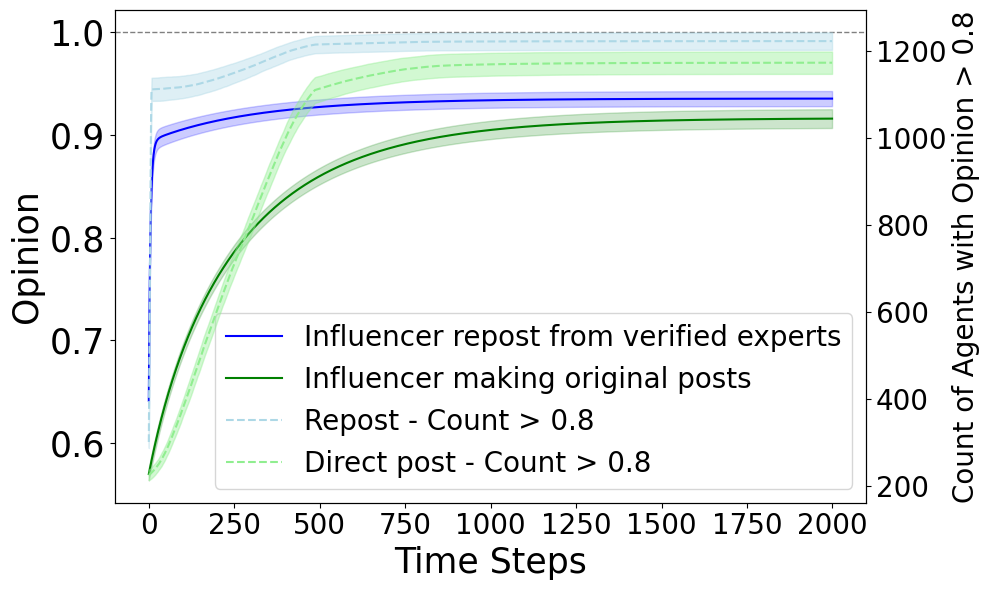

In [69]:
plt.figure(figsize=(10, 6))

# Primary axis for average opinion
ax1 = plt.gca()

# Plot mean opinion lines
line1 = ax1.plot(mean_opinion_s6, label='Influencer repost from verified experts', color='blue')
line2 = ax1.plot(mean_opinion_s5, label='Influencer making original posts', color='green')

# Plot std fill for opinion
ax1.fill_between(range(max_iteration),
                 mean_opinion_s6 - std_opinion_s6,
                 mean_opinion_s6 + std_opinion_s6,
                 alpha=0.2, color='blue', label='S6: ±1 Std Dev')

ax1.fill_between(range(max_iteration),
                 mean_opinion_s5 - std_opinion_s5,
                 mean_opinion_s5 + std_opinion_s5,
                 alpha=0.2, color='green', label='S5: ±1 Std Dev')

ax1.axhline(y=1, color='grey', linewidth=1, linestyle='--')
ax1.set_xlabel('Time Steps', fontsize=25)
ax1.set_ylabel('Opinion', fontsize=25)
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=25)
# ax1.set_ylim(0.5, 1.1)

# Secondary axis for count above 0.8
ax2 = ax1.twinx()

line3 = ax2.plot(mean_count_above_08_s6, label='Repost - Count > 0.8', color='lightblue', linestyle='--')
line4 = ax2.plot(mean_count_above_08_s5, label='Direct post - Count > 0.8', color='lightgreen', linestyle='--')

ax2.fill_between(range(max_iteration),
                 mean_count_above_08_s6 - std_count_above_08_s6,
                 mean_count_above_08_s6 + std_count_above_08_s6,
                 alpha=0.4, color='lightblue')

ax2.fill_between(range(max_iteration),
                 mean_count_above_08_s5 - std_count_above_08_s5,
                 mean_count_above_08_s5 + std_count_above_08_s5,
                 alpha=0.4, color='lightgreen')

ax2.set_ylabel('Count of Agents with Opinion > 0.8', fontsize=20)
ax2.tick_params(axis='y', labelsize=20)

# Combine legends from both axes
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=20)

# plt.title('E3 - Average Opinion & High-Opinion Agent Count (100 Simulations)', fontsize=22)
plt.tight_layout()
plt.show()

In [71]:
import json

data_to_store = {
    "mean_opinion_s5": mean_opinion_s5.tolist(),
    "std_opinion_s5": std_opinion_s5.tolist(),
    "mean_opinion_s6": mean_opinion_s6.tolist(),
    "std_opinion_s6": std_opinion_s6.tolist(),
    "mean_count_above_08_s5": mean_count_above_08_s5.tolist(),
    "std_count_above_08_s5": std_count_above_08_s5.tolist(),
    "mean_count_above_08_s6": mean_count_above_08_s6.tolist(),
    "std_count_above_08_s6": std_count_above_08_s6.tolist(),
    "all_opinions_s5": all_opinions_s5.tolist(),
    "all_opinions_s6": all_opinions_s6.tolist(),
    "all_counts_above_08_s5": all_counts_above_08_s5.tolist(), 
    "all_counts_above_08_s6": all_counts_above_08.tolist()
}

# Save to a JSON file
with open("E3_plot_data.json", "w") as f:
    json.dump(data_to_store, f)

In [ ]:
import json

# Convert np arrays to lists
data_to_store = {
    "all_opinions_s6": all_opinions_s6.tolist(),
    "all_opinions_s5": all_opinions_s5.tolist()
}

# Save to file
with open("E3_opinions_data.json", "w") as f:
    json.dump(data_to_store, f)

E4

In [ ]:
all_opinions_s7 = []

for run in range(num_runs):
    random_state = np.random.RandomState(random_seed + run) 
    G = SF_26.SFNetwork(100, 1400, 0, 30, 0, 100, 0, random_state)
    G.boost_doctor_visibility()
    opinion_history, num_nodes, time_steps = run_sim(G, max_iteration)
    
    ave_opinion = [np.average(opinion_history[t]) for t in time_steps]

    if len(ave_opinion) < max_iteration:
        ave_opinion += [ave_opinion[-1]] * (max_iteration - len(ave_opinion))
    
    all_opinions_s7.append(ave_opinion[:max_iteration])

all_opinions_s7 = np.array(all_opinions_s7) 
mean_opinion_s7 = np.mean(all_opinions_s7, axis=0)
std_opinion_s7 = np.std(all_opinions_s7, axis=0)

In [ ]:
all_opinions_s8 = []

for run in range(num_runs):
    random_state = np.random.RandomState(random_seed + run) 
    G = SF_26.SFNetwork(100, 1400, 0, 30, 0, 0, 0, random_state)
    G.boost_doctor_visibility()
    opinion_history, num_nodes, time_steps = run_sim(G, max_iteration)
    
    ave_opinion = [np.average(opinion_history[t]) for t in time_steps]

    if len(ave_opinion) < max_iteration:
        ave_opinion += [ave_opinion[-1]] * (max_iteration - len(ave_opinion))
    
    all_opinions_s8.append(ave_opinion[:max_iteration])

all_opinions_s8 = np.array(all_opinions_s8)  
mean_opinion_s8 = np.mean(all_opinions_s8, axis=0)
std_opinion_s8 = np.std(all_opinions_s8, axis=0)

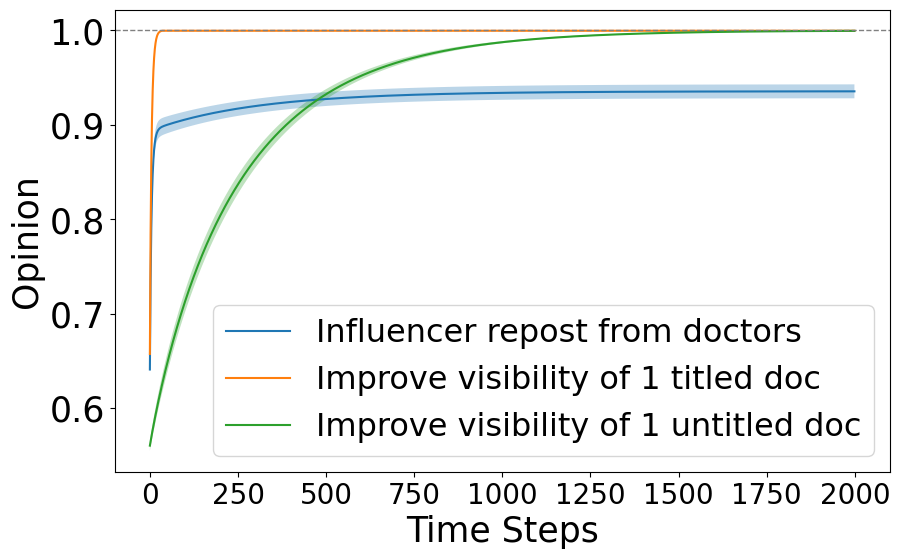

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(mean_opinion_s6, label='Influencer repost from doctors')
plt.plot(mean_opinion_s7, label='Improve visibility of 1 titled doc')
plt.plot(mean_opinion_s8, label='Improve visibility of 1 untitled doc')
plt.fill_between(range(max_iteration), mean_opinion_s6 - std_opinion_s6, mean_opinion_s6 + std_opinion_s6, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_s7 - std_opinion_s7, mean_opinion_s7 + std_opinion_s7, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_s8 - std_opinion_s8, mean_opinion_s8 + std_opinion_s8, alpha=0.3)
plt.axhline(y=1, color='grey', linewidth=1, linestyle='--')
plt.xlabel('Time Steps', fontsize =25)
plt.ylabel('Opinion', fontsize=25)
# plt.title('E3 - Average Opinion Over Time of 100 Simulations',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.legend(fontsize=23)
# plt.grid(True)
plt.show()

In [72]:
import json

plot_data = {
    "mean_opinion_s6": mean_opinion_s6.tolist(),
    "std_opinion_s6": std_opinion_s6.tolist(),
    "mean_opinion_s7": mean_opinion_s7.tolist(),
    "std_opinion_s7": std_opinion_s7.tolist(),
    "mean_opinion_s8": mean_opinion_s8.tolist(),
    "std_opinion_s8": std_opinion_s8.tolist(),
    "all_opinions_s6": all_opinions_s6.tolist(),
    "all_opinions_s7": all_opinions_s7.tolist(),
    "all_opinions_s8": all_opinions_s8.tolist()
}

# Save to a file
with open("E4_plot_data.json", "w") as f:
    json.dump(plot_data, f)